# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 4. Modelos alternativos
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Modelo 5 Gradient Boosting (XGBoost)

XGBoost, que significa "eXtreme Gradient Boosting", es uno de los algoritmos de machine learning más potentes y populares en la actualidad, especialmente para datos tabulares. Pertenece a la familia de modelos de "ensamble", lo que significa que construye un pronóstico final muy preciso a partir de la combinación de muchos modelos más débiles, específicamente árboles de decisión. Su estrategia consiste en crear estos árboles de forma secuencial, donde cada nuevo árbol se entrena para corregir los errores que cometieron los anteriores. La "X" de "eXtreme" se refiere a las optimizaciones de ingeniería que lo hacen increíblemente rápido y eficiente, además de incorporar técnicas de regularización para prevenir el sobreajuste, convirtiéndolo en la opción predilecta en competencias de ciencia de datos y aplicaciones industriales.

## Librerías

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Flatten
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score

2025-10-19 22:41:23.955668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-19 22:41:23.987944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760935284.011723   37189 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760935284.019577   37189 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760935284.043277   37189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Carga de Datos

In [2]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /mnt/d/Code/MNA/lsm/TC5035-PI-E51/Avance4/processed_data_pipeline 
VIDEOS DIRECTORY: /mnt/d/Code/MNA/lsm/TC5035-PI-E51/Avance4/data/videos


In [3]:
# --- Cargar los Datos Preprocesados ---
print("--- Cargando datos preprocesados ---")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, "X_test.npy"))
y_train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_test.csv"))
y_train_labels = y_train_df['class'].values
y_test_labels = y_test_df['class'].values

# Esta función convierte una secuencia (150, 5) en un vector de características plano
def create_features(sequence_data):
    num_samples = sequence_data.shape[0]
    # Calcularemos 6 estadísticas para cada una de las 5 mediciones = 30 características
    features = np.zeros((num_samples, 5 * 6))
    
    for i in range(num_samples):
        sample = sequence_data[i]
        # Para cada una de las 5 mediciones...
        feature_vector = []
        for j in range(5):
            measurement = sample[:, j]
            feature_vector.append(np.mean(measurement))
            feature_vector.append(np.std(measurement))
            feature_vector.append(np.min(measurement))
            feature_vector.append(np.max(measurement))
            feature_vector.append(np.median(measurement))
            feature_vector.append(np.var(measurement))
        features[i] = np.array(feature_vector)
        
    return features

X_train_features = create_features(X_train)
X_test_features = create_features(X_test)

print(f"X_train forma: {X_train_features.shape}")
print(f"X_test forma: {X_test_features.shape}")

# --- Codificar las Etiquetas ---
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels)
y_test_encoded = label_encoder.transform(y_test_labels)

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_features,
    y_train_encoded,
    test_size=0.2, # Usamos el 20% de los datos de entrenamiento para validar
    random_state=42,
    stratify=y_train_encoded # Mantiene la proporción de clases
)


--- Cargando datos preprocesados ---
X_train forma: (164, 30)
X_test forma: (41, 30)


## Modelo 5 Gradient Boosting (XGBoost)

In [4]:
# --- Construir el Modelo ---
print("\n--- Construyendo la arquitectura del modelo XGBoost ---")
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    use_label_encoder=False,
    eval_metric='mlogloss'
)


--- Construyendo la arquitectura del modelo XGBoost ---


## Entrenamiento

In [5]:
model.fit(
    X_train_split,
    y_train_split,
    eval_set=[(X_val, y_val)],
    verbose=True
)

/home/raven/miniconda3/envs/lsm/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [22:41:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:0.96643
[1]	validation_0-mlogloss:0.73417
[2]	validation_0-mlogloss:0.60741
[3]	validation_0-mlogloss:0.49486
[4]	validation_0-mlogloss:0.41479
[5]	validation_0-mlogloss:0.35728
[6]	validation_0-mlogloss:0.31266
[7]	validation_0-mlogloss:0.29320
[8]	validation_0-mlogloss:0.26224
[9]	validation_0-mlogloss:0.25612
[10]	validation_0-mlogloss:0.24046
[11]	validation_0-mlogloss:0.21831
[12]	validation_0-mlogloss:0.20159
[13]	validation_0-mlogloss:0.19401
[14]	validation_0-mlogloss:0.18309
[15]	validation_0-mlogloss:0.17518
[16]	validation_0-mlogloss:0.17326
[17]	validation_0-mlogloss:0.16887
[18]	validation_0-mlogloss:0.16534
[19]	validation_0-mlogloss:0.16280
[20]	validation_0-mlogloss:0.15894
[21]	validation_0-mlogloss:0.15676
[22]	validation_0-mlogloss:0.15692
[23]	validation_0-mlogloss:0.15494
[24]	validation_0-mlogloss:0.15520
[25]	validation_0-mlogloss:0.15202
[26]	validation_0-mlogloss:0.15368
[27]	validation_0-mlogloss:0.15097
[28]	validation_0-mlogloss:0.1

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


## Resultado

In [6]:
# --- Evaluar y Visualizar los Resultados ---
print("\n--- Evaluando el modelo con métricas detalladas ---")

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test_features)
report = classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_)
print(report)


--- Evaluando el modelo con métricas detalladas ---
              precision    recall  f1-score   support

       Abrir       1.00      1.00      1.00        10
      Avión       1.00      1.00      1.00        10
      Borrar       1.00      1.00      1.00        11
          Tu       1.00      1.00      1.00        10

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [7]:
# Generar y mostrar el Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
# Reporte: precisión, recall y f1-score para cada clase.
report = classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_)
print(report)

# Accuracy (Precisión Global)
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"La precisión (accuracy) del modelo es: {accuracy:.2f}")

# Recall
recall = recall_score(y_test_encoded, y_pred, average='weighted')
print(f"El recall (weighted) del modelo es: {recall:.2f}")

# F1-score
f1 = f1_score(y_test_encoded, y_pred, average='weighted')
print(f"El F1-score (weighted) del modelo es: {f1:.2f}")


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Abrir       1.00      1.00      1.00        10
      Avión       1.00      1.00      1.00        10
      Borrar       1.00      1.00      1.00        11
          Tu       1.00      1.00      1.00        10

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

La precisión (accuracy) del modelo es: 1.00
El recall (weighted) del modelo es: 1.00
El F1-score (weighted) del modelo es: 1.00



--- Matriz de Confusión ---


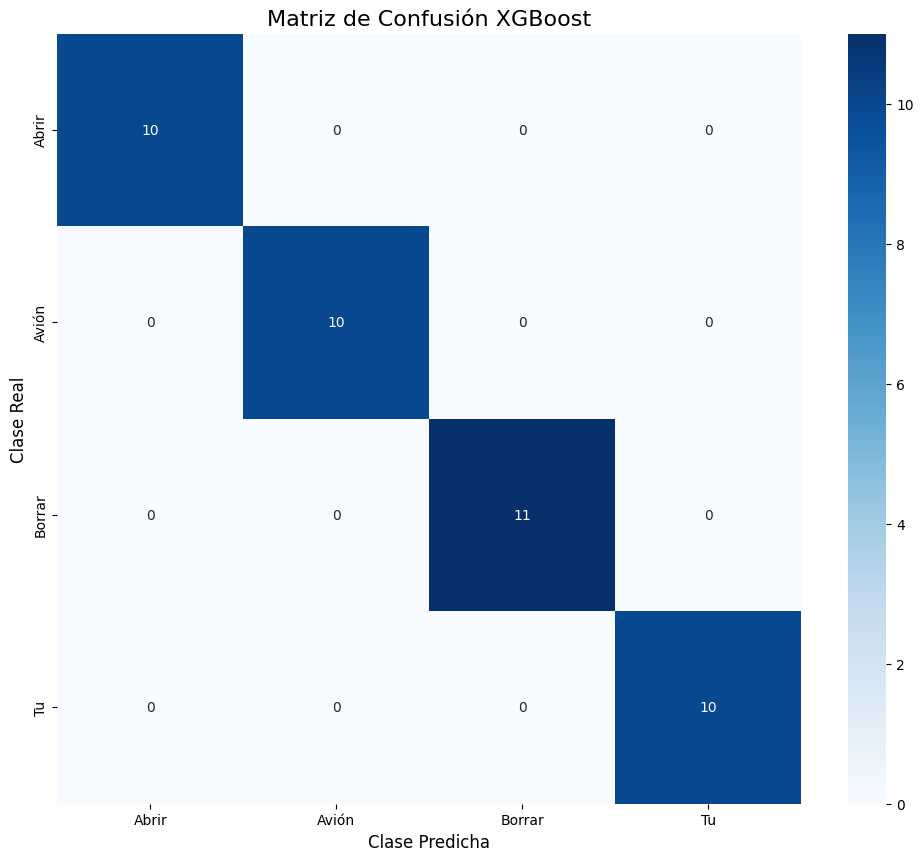


Entrenamiento completado!


In [8]:
# Generar y mostrar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión XGBoost', fontsize=16)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.show()

print("\nEntrenamiento completado!")